# Validating the Code — v2

Author: Vicente Pedreros A.

The goal of this notebook is to validate `VP_pert` against `CLASS`.
This is a corrected version of `validating.ipynb` fixing:
- Adiabatic initial conditions for the DE fluid in `run_vp`
- Correct CLASS field names for DE perturbations (`delta_rho_fld`, `rho_plus_p_theta_fld`)
- Density-weighted matter theta from CLASS
- Variable naming (CLASS vs VP\_pert was swapped in the original)
- `struct_cleanup()` moved to the final cell

In [8]:
import numpy as np

import matplotlib.pyplot as plt
import scienceplots
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
plt.style.use(['science', 'bright', 'vpedre'])

import VP_pert as vp
from classy import Class
from scipy.integrate import solve_ivp

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [9]:
# Cosmological parameters (EuclidEmulator2 centre values)
H0_kms = 67.00
h      = H0_kms / 100
Om_b   = 0.049
Om_cdm = 0.27
Om_m   = Om_b + Om_cdm
Om_de  = 1.0 - Om_m          # flat universe

vp_base = {
    'H0 (km/s/Mpc)': H0_kms,
    'H0 (1/Mpc)'   : H0_kms / vp.c_kms,
    'h'            : h,
    'Omega_c0'     : Om_cdm,
    'Omega_b0'     : Om_b,
    'Omega_m0'     : Om_m,
    'cs2'          : 1.0,
}

# DE model catalogue  {label: (w0, wa)}
de_models = {
    r'$\Lambda$CDM'            : (-1.0,  0.0),
    r'$w_0=-0.7,\,w_a=0.0$'  : (-0.7, 0.0),
    r'$w_0=-1.3,\,w_a=0.0$'   : (-1.3,  0.0),
    # r'$w_0=-0.7,\,w_a=0.6$'   : (-0.7,  0.6),
}

k_default = 200 * vp_base['H0 (1/Mpc)']

In [10]:
def run_class(w0=-1.0, wa=0.0):
    params = {
        'output'         : 'mPk, mTk',
        'gauge'          : 'newtonian',
        'h'              : h,
        'Omega_b'        : Om_b,
        'Omega_cdm'      : Om_cdm,
        'N_ncdm'         : 0,
        'N_ur'           : 3.046,
        'P_k_max_1/Mpc'  : 10.0,
        'z_max_pk'       : 100.0,
        'k_output_values': k_default,
    }
    if w0 == -1.0 and wa == 0.0:
        params['Omega_Lambda'] = Om_de
    else:
        params['Omega_fld'] = Om_de
        params['w0_fld']    = w0
        params['wa_fld']    = wa
        params['cs2_fld']   = 1.0
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    return cosmo


def run_vp(w0=-1.0, wa=0.0, k=k_default, a_ini=1e-3):
    """
    Integrate from a_ini (default z=99) to a=1.

    Matter IC: pure growing mode
      vm = -f * a * H(a) * delta_m,  f = Omega_m^0.55

    DE IC: sub-horizon quasi-static attractor (cs2=1, k >> aH)
      The QS limit of the DE equations gives  cs2*delta_de + (1+w)*phi = 0,
      so  delta_de = -(1+w)*phi / cs2,  vde = 0.
      Starting away from this attractor by delta_de=0 excites an oscillating
      homogeneous mode whose amplitude is comparable to the CLASS signal at z=0.
    """
    p = dict(vp_base)
    p['w0'], p['wa'] = w0, wa

    w_ini = vp.w_de(a_ini, pars=p)
    H_ini = vp.Hubble(a_ini, pars=p)
    cs2   = p['cs2']

    # Growing-mode IC for matter (amplitude irrelevant — normalized to z=0)
    delta_m_ini = 4/3 * 1e-5
    f_ini       = vp.Omega_m(a_ini, pars=p) ** 0.55     # Linder growth rate
    vm_ini      = -f_ini * a_ini * H_ini * delta_m_ini  # conformal-time theta_m

    # Gravitational potential from matter only (DE contribution is O((1+w)*(aH/k)^2))
    phi_m = vp.k2phi(a_ini, k,
                     [delta_m_ini, vm_ini, 0.0, 0.0, 0.0],
                     pars=p) / k**2

    # Quasi-static DE IC:  cs2*delta_de + (1+w)*phi = 0
    delta_de_ini = -(1.0 + w_ini) * phi_m / cs2
    vde_ini      = 0.0

    # Recompute phi self-consistently with the DE perturbation included
    phi_ini = vp.k2phi(a_ini, k,
                       [delta_m_ini, vm_ini, delta_de_ini, vde_ini, 0.0],
                       pars=p) / k**2

    sol = solve_ivp(
        vp.rhs_pert, (a_ini, 1.0),
        [delta_m_ini, vm_ini, delta_de_ini, vde_ini, phi_ini],
        args=(k, p), method='RK45', dense_output=True, rtol=1e-9, atol=1e-12,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol, p


def class_perts(cosmo, pars, z_max=999):
    """
    Return (z, delta_m, V_m, delta_de, V_de, phi) from CLASS at k = k_default.

    CLASS stores DE fluid perturbations as:
      delta_rho_fld          = rho_fld * delta_de        [units of (.)rho_fld]
      rho_plus_p_theta_fld   = (1+w) * rho_fld * theta_de
    Dividing by rho_fld from get_background() recovers the dimensionless contrasts.
    Matter theta is density-weighted: theta_m = (Om_cdm*theta_cdm + Om_b*theta_b) / Om_m.
    phi is the Newtonian potential output directly by CLASS.
    """
    pert  = cosmo.get_perturbations()['scalar'][0]
    bg    = cosmo.get_background()

    a_all = pert['a']
    mask  = a_all > 1.0 / (1.0 + z_max)
    a     = a_all[mask]

    delta_m = (Om_cdm * pert['delta_cdm'][mask] + Om_b * pert['delta_b'][mask]) / Om_m
    theta_m = (Om_cdm * pert['theta_cdm'][mask] + Om_b * pert['theta_b'][mask]) / Om_m
    V_m = theta_m

    if 'delta_rho_fld' in pert:
        a_bg       = 1.0 / (1.0 + bg['z'])
        rho_interp = interp1d(a_bg, bg['(.)rho_fld'], bounds_error=False, fill_value='extrapolate')
        rho_bg     = rho_interp(a)
        delta_de   = pert['delta_rho_fld'][mask]        / rho_bg
        V_de       = pert['rho_plus_p_theta_fld'][mask] / rho_bg
    else:
        delta_de = np.zeros_like(a)
        V_de     = np.zeros_like(a)

    phi_cl = pert['phi'][mask]

    return 1.0 / a - 1.0, delta_m, V_m, delta_de, V_de, phi_cl


def vp_perts(sol, z_arr):
    """
    Return (delta_m, theta_m, delta_de, theta_de, phi) from VP_pert at redshifts z_arr.

    VP_pert state: [delta_m, vm, delta_de, vde, phi]
    vm and vde are conformal-time velocity divergences (theta in conformal time),
    identical to what CLASS outputs as theta_cdm / theta_fld.
    No division by a is needed.
    """
    a        = 1.0 / (1.0 + np.asarray(z_arr))
    states   = sol.sol(a).T          # shape (n_points, 5)
    delta_m  = states[:, 0]
    theta_m  = states[:, 1]   # vm = theta_m (conformal-time velocity divergence)
    delta_de = states[:, 2]
    theta_de = states[:, 3]   # vde = (1+w)*theta_de, matching CLASS rho_plus_p_theta_fld/rho
    phi      = states[:, 4]
    return delta_m, theta_m, delta_de, theta_de, phi


print('Helpers defined.')

Helpers defined.


In [11]:
class_cosmos = {}
cl_data      = {}   # {label: dict(z, delta_m, V_m, delta_de, V_DE, phi)}
vp_data      = {}   # {label: dict(delta_m, V_m, delta_de, V_DE, phi)}

for lbl, (w0, wa) in de_models.items():
    pars   = {**vp_base, 'w0': w0, 'wa': wa}
    cosmo  = run_class(w0, wa)
    sol, _ = run_vp(w0, wa)

    z, dm_cl, tm_cl, dde_cl, tde_cl, phi_cl = class_perts(cosmo, pars)
    dm_vp, tm_vp, dde_vp, tde_vp, phi_vp    = vp_perts(sol, z)

    class_cosmos[lbl] = cosmo
    cl_data[lbl] = dict(z=z, delta_m=dm_cl, V_m=tm_cl, delta_de=dde_cl, V_DE=tde_cl, phi=phi_cl)
    vp_data[lbl] = dict(delta_m=dm_vp, V_m=tm_vp, delta_de=dde_vp, V_DE=tde_vp, phi=phi_vp)

    print(f'  {lbl}: done')

print('All models computed.')

  $\Lambda$CDM: done
  $w_0=-0.7,\,w_a=0.0$: done
  $w_0=-1.3,\,w_a=0.0$: done
All models computed.


## 1 — Dimensionless Hubble Rate $E(z)$

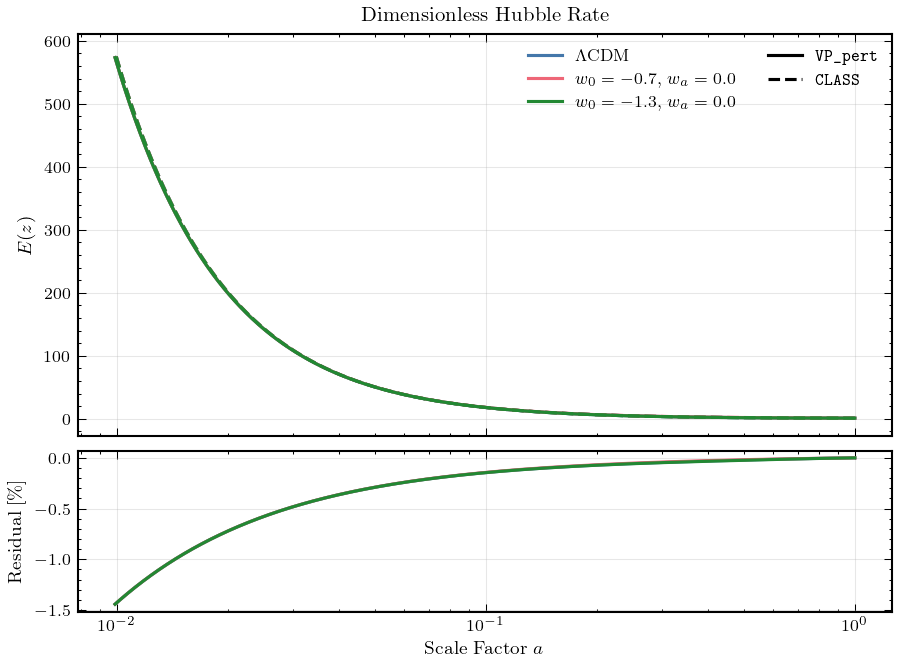

In [12]:
z_ini = 100
zz = np.linspace(0, z_ini, 1000)
aa = 1.0 / (1.0 + zz)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for idx, (label, (w0, wa)) in enumerate(de_models.items()):
    p = {**vp_base, 'w0': w0, 'wa': wa}
    E_vp = vp.EHubble(aa, pars=p)
    E_cl = np.array([class_cosmos[label].Hubble(z) / class_cosmos[label].Hubble(0) for z in zz])
    ax1.semilogx(aa, E_vp, color=COLORS[idx], label=label)
    ax1.semilogx(aa, E_cl, color=COLORS[idx], ls='--')
    ax2.plot(aa, 100 * (E_vp / E_cl - 1.0), color=COLORS[idx])

proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
         Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles=handles + proxy, ncol=2)
ax1.set_ylabel(r'$E(z)$')
ax2.set_xlabel(r'Scale Factor $a$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())
# ax1.invert_xaxis()
ax1.set_title('Dimensionless Hubble Rate')
plt.savefig('figs/E_z.pdf', bbox_inches='tight')
plt.show()

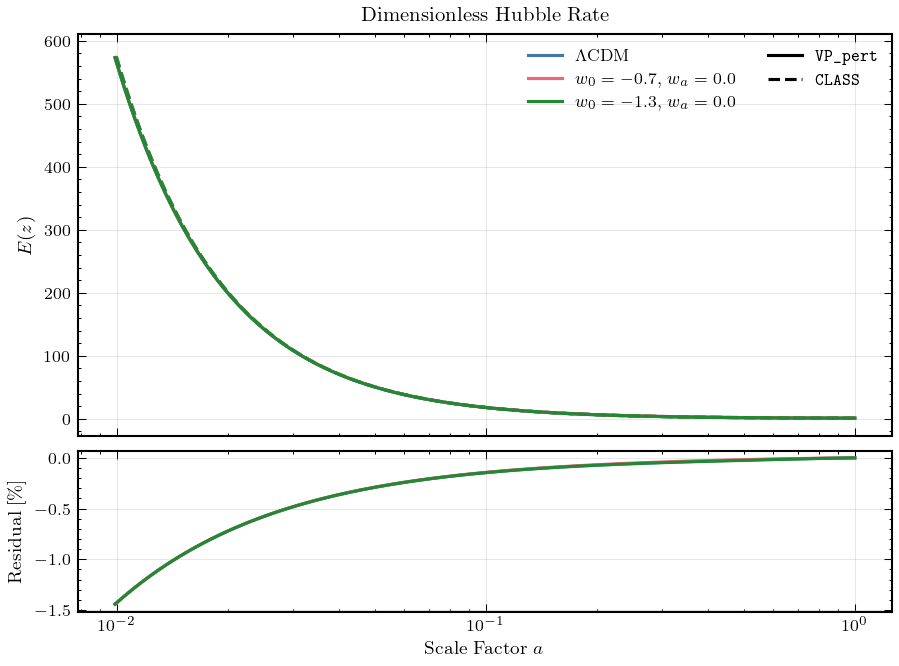

In [13]:
z_ini = 100
zz = np.linspace(0, z_ini, 1000)
aa = 1.0 / (1.0 + zz)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for idx, (label, (w0, wa)) in enumerate(de_models.items()):
    p = {**vp_base, 'w0': w0, 'wa': wa}
    E_vp = vp.EHubble(aa, pars=p)
    E_vp_r = vp.EHubble_rad(aa, pars=p)
    ax1.semilogx(aa, E_vp, color=COLORS[idx], label=label)
    ax1.semilogx(aa, E_vp_r, color=COLORS[idx], ls='--')
    ax2.plot(aa, 100 * (E_vp / E_vp_r - 1.0), color=COLORS[idx])

proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
         Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles=handles + proxy, ncol=2)
ax1.set_ylabel(r'$E(z)$')
ax2.set_xlabel(r'Scale Factor $a$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())
# ax1.invert_xaxis()
ax1.set_title('Dimensionless Hubble Rate')
plt.savefig('figs/E_z_vp_rad.pdf', bbox_inches='tight')
plt.show()

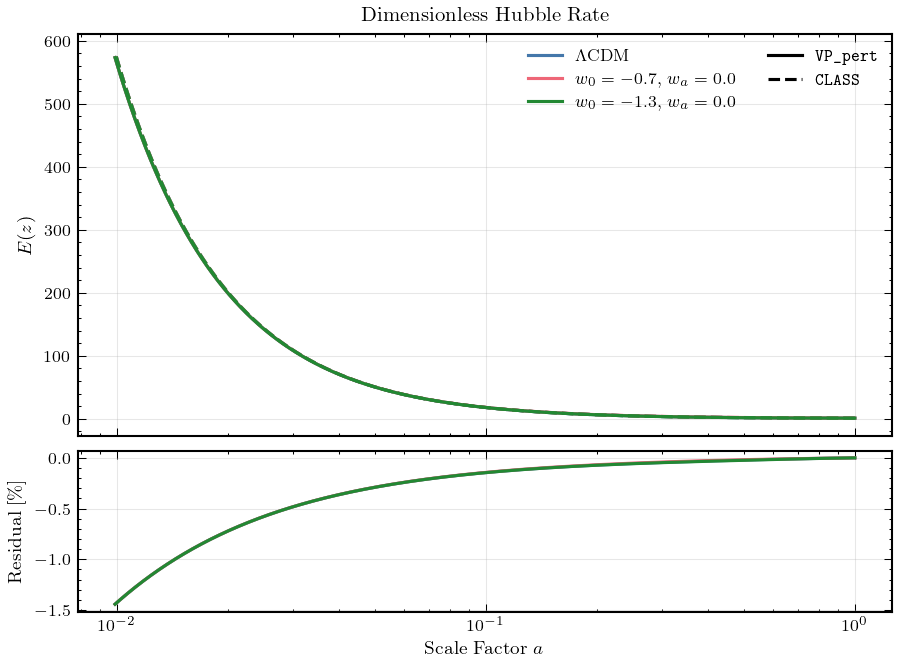

In [14]:
z_ini = 100
zz = np.linspace(0, z_ini, 1000)
aa = 1.0 / (1.0 + zz)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for idx, (label, (w0, wa)) in enumerate(de_models.items()):
    p = {**vp_base, 'w0': w0, 'wa': wa}
    E_vp = vp.EHubble(aa, pars=p)
    E_cl = np.array([class_cosmos[label].Hubble(z) / class_cosmos[label].Hubble(0) for z in zz])
    ax1.semilogx(aa, E_vp, color=COLORS[idx], label=label)
    ax1.semilogx(aa, E_cl, color=COLORS[idx], ls='--')
    ax2.plot(aa, 100 * (E_vp / E_cl - 1.0), color=COLORS[idx])

proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
         Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles=handles + proxy, ncol=2)
ax1.set_ylabel(r'$E(z)$')
ax2.set_xlabel(r'Scale Factor $a$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())
# ax1.invert_xaxis()
ax1.set_title('Dimensionless Hubble Rate')
plt.savefig('figs/E_z.pdf', bbox_inches='tight')
plt.show()

In [15]:
def plot_hubble():
    z_ini = 1000
    zz = np.linspace(0, z_ini, 10000)
    aa = 1.0 / (1.0 + zz)

    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(10, 6), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

    for idx, (label, (w0, wa)) in enumerate(de_models.items()):
        p = {**vp_base, 'w0': w0, 'wa': wa}
        E_vp = vp.EHubble(aa, pars=p)
        E_vp_rad = vp.EHubble_rad(aa, pars=p)
        E_cl = np.array([class_cosmos[label].Hubble(z) / class_cosmos[label].Hubble(0) for z in zz])
        ax1[0].semilogx(aa, E_vp,                       color=COLORS[idx],alpha=0.7, label=label)
        ax1[0].semilogx(aa, E_cl,                       color=COLORS[idx],alpha=0.7, ls='--')
        ax2[0].plot(    aa, 100 * (E_vp / E_cl - 1.0),  color=COLORS[idx],alpha=0.7,)

        ax1[1].semilogx(aa, E_vp_rad,                       color=COLORS[idx],alpha=0.7, label=label)
        ax1[1].semilogx(aa, E_cl,                           color=COLORS[idx],alpha=0.7, ls='--')
        ax2[1].plot(    aa, 100 * (E_vp_rad / E_cl - 1.0),  color=COLORS[idx],alpha=0.7,)

    proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
             Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
    handles, _ = ax1[0].get_legend_handles_labels()
    ax1[0].legend(handles=handles + proxy, ncol=2)
    ax1[0].set_ylabel(r'$E(a)$')
    ax2[0].set_xlabel(r'Scale Factor $a$')
    ax2[0].set_ylabel(r'Residual [\%]')
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator())

    proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
             Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
    handles, _ = ax1[1].get_legend_handles_labels()
    ax1[1].legend(handles=handles + proxy, ncol=2)
    # ax1[1].set_ylabel(r'$E(a)$')
    ax2[1].set_xlabel(r'Scale Factor $a$')
    # ax2[1].set_ylabel(r'Residual [\%]')
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator())

    ax1[0].set_title(r'No radiation compared to \texttt{CLASS}')
    ax1[1].set_title(r'Radiation compared to \texttt{CLASS}')
    
    fig.suptitle('Dimensionless Hubble Rate')
    plt.savefig('figs/E_z.pdf', bbox_inches='tight')

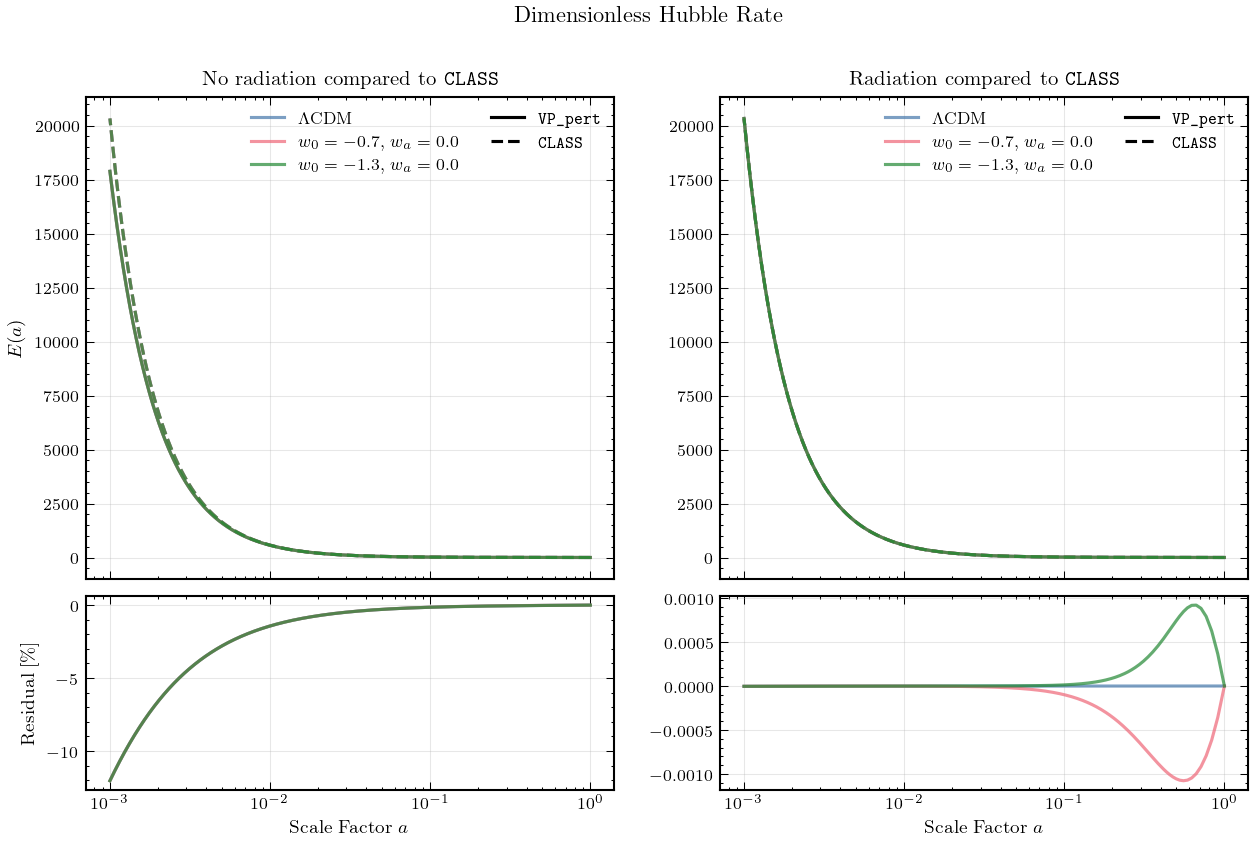

In [16]:
plot_hubble()

In [35]:
breaking_points = {}

for label, (w0, wa) in de_models.items():
    p = {**vp_base, 'w0': w0, 'wa': wa}
    
    E_vp = vp.EHubble(aa, pars=p)
    E_cl = np.array([class_cosmos[label].Hubble(z) / class_cosmos[label].Hubble(0) for z in zz])

    rel_diff = np.abs((E_vp / E_cl) - 1.0) * 100

    invalid_indices = np.where(rel_diff > 1.0)[0]
    
    if len(invalid_indices) > 0:
        # Get the first index where the condition was met
        first_idx = invalid_indices[0]
        breaking_points[label] = {
            'a': aa[first_idx],
            'z': zz[first_idx],
            'error': rel_diff[first_idx]
        }
        print(f"Model {label} exceeds 1% error at a = {aa[first_idx]:.4f} (z = {zz[first_idx]:.1f})")
    else:
        breaking_points[label] = None
        print(f"Model {label} stays within 1% error for the entire range.")

Model $\Lambda$CDM exceeds 1% error at a = 0.0144 (z = 68.5)
Model $w_0=-0.7,\,w_a=0.0$ exceeds 1% error at a = 0.0144 (z = 68.6)
Model $w_0=-1.3,\,w_a=0.0$ exceeds 1% error at a = 0.0144 (z = 68.5)


## 2 — Matter Overdensity $\delta_{\rm m}(z)$

Normalized to $\delta_{\rm m}(z=0) = 1$ independently for each code.

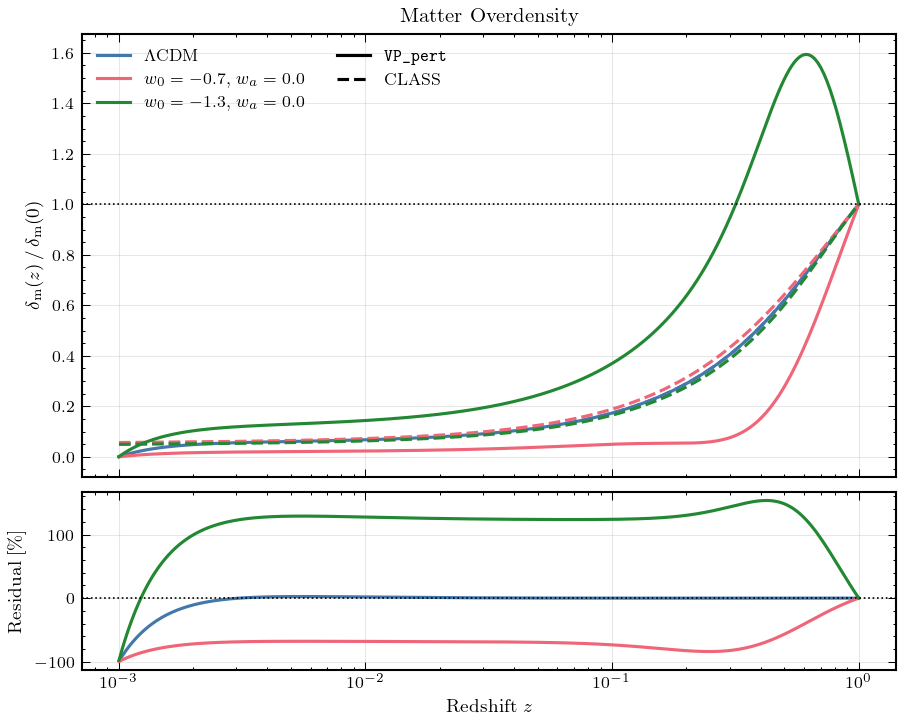

In [45]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (lbl, (w0, wa)) in enumerate(de_models.items()):
    z    = cl_data[lbl]['z']
    aa = 1 / (1+z)
    y_cl = cl_data[lbl]['delta_m']
    y_vp = vp_data[lbl]['delta_m']
    y_cl_n = y_cl / y_cl[-1]
    y_vp_n = y_vp / y_vp[-1]
    ax1.semilogx(aa, y_cl_n, color=COLORS[i], ls='--', lw=1.5)
    ax1.semilogx(aa, y_vp_n, color=COLORS[i], lw=1.5, label=lbl)
    ax2.semilogx(aa, 100 * (y_vp_n / y_cl_n - 1), color=COLORS[i])

handles, _ = ax1.get_legend_handles_labels()
custom = [Line2D([0],[0], color='k', lw=1.5,        label=r'\texttt{VP\_pert}'),
          Line2D([0],[0], color='k', lw=1.5, ls='--', label='CLASS')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)
ax1.axhline(1, color='k', lw=0.8, ls=':')
ax1.set_ylabel(r'$\delta_{\rm m}(z)\,/\,\delta_{\rm m}(0)$')
ax1.set_title('Matter Overdensity')
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())

plt.savefig('figs/delta_m.pdf', bbox_inches='tight')
plt.show()

In [114]:
def plot_matter():
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(10, 6), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

    for i, (lbl, (w0, wa)) in enumerate(de_models.items()):
        z    = cl_data[lbl]['z']
        aa = 1 / (1+z)
        dm_cl = cl_data[lbl]['delta_m']
        dm_vp = vp_data[lbl]['delta_m']
        dm_cl_n = dm_cl / dm_cl[-1]
        dm_vp_n = dm_vp / dm_vp[-1]

        vm_cl = cl_data[lbl]['V_m']
        vm_vp = vp_data[lbl]['V_m']
        vm_cl_n = vm_cl / vm_cl[-1]
        vm_vp_n = vm_vp / vm_vp[-1]

        ax1[0].semilogx(aa, dm_cl_n,                        color=COLORS[i],alpha=0.7, ls='--', lw=1.5)
        ax1[0].semilogx(aa, dm_vp_n,                        color=COLORS[i],alpha=0.7, lw=1.5, label=lbl)
        ax2[0].semilogx(aa, 100 * (dm_vp_n / dm_cl_n - 1),   color=COLORS[i],alpha=0.7,)

        ax1[1].semilogx(aa, vm_cl_n, color=COLORS[i], ls='--', lw=1.5)
        ax1[1].semilogx(aa, vm_vp_n, color=COLORS[i], lw=1.5, label=lbl)
        ax2[1].semilogx(aa, 100 * (vm_vp_n / vm_cl_n - 1), color=COLORS[i])

    proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
             Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
    handles, _ = ax1[0].get_legend_handles_labels()
    ax1[0].legend(handles=handles + custom, fontsize=8, ncol=2)
    ax1[0].axhline(1, color='k', lw=0.8, ls=':')
    ax1[0].set_ylabel(r'$\delta_{\rm m}(z)\,/\,\delta_{\rm m}(0)$')
    ax2[0].set_xlabel(r'Scale Factor $a$')
    ax2[0].set_ylabel(r'Residual [\%]')
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator())

    proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
             Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
    handles, _ = ax1[1].get_legend_handles_labels()
    ax1[1].legend(handles=handles + proxy, ncol=2)
    ax1[1].set_ylabel(r'$V_{\rm m}(z)\,/\,V_{\rm m}(0)$')
    ax2[1].set_xlabel(r'Scale Factor $a$')
    ax2[1].set_ylabel(r'Residual [\%]')
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator())

    ax1[0].set_title(r'Overdensity')
    ax1[1].set_title(r'Velocity Perturbation')
    
    fig.suptitle('Linear Cold Dark Matter Perturbations')
    plt.savefig('figs/matter_perturbations.pdf', bbox_inches='tight')

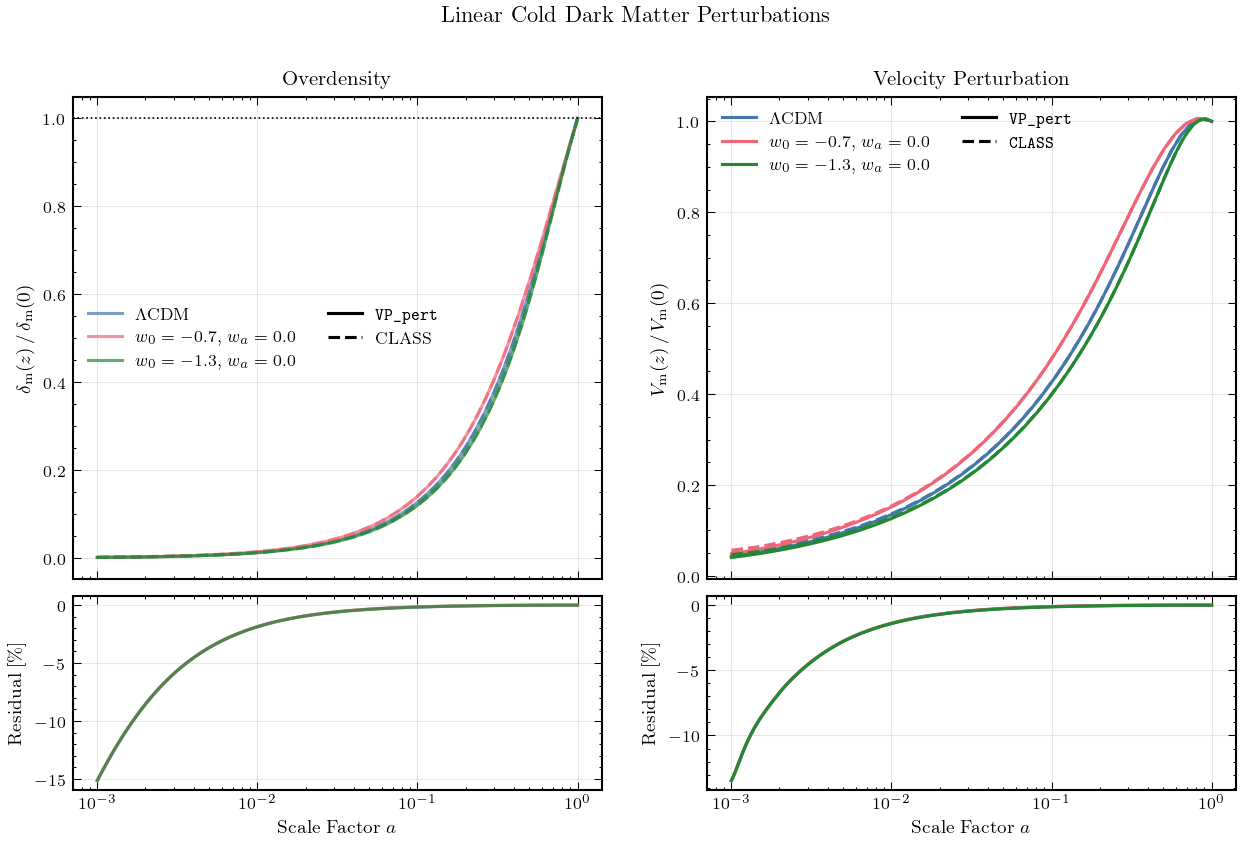

In [115]:
plot_matter()

## 3 — Matter Velocity Perturbation $V_{\rm m}(z)$

<!-- VP\_pert stores $v_m$ which equals the conformal-time velocity divergence $\theta_m$ directly
(verified by matching the Euler equation structure with CLASS).
CLASS gives `theta_cdm` and `theta_b`; we use the density-weighted average.
Normalized to $\theta_m(z=0) = 1$ independently for each code. -->

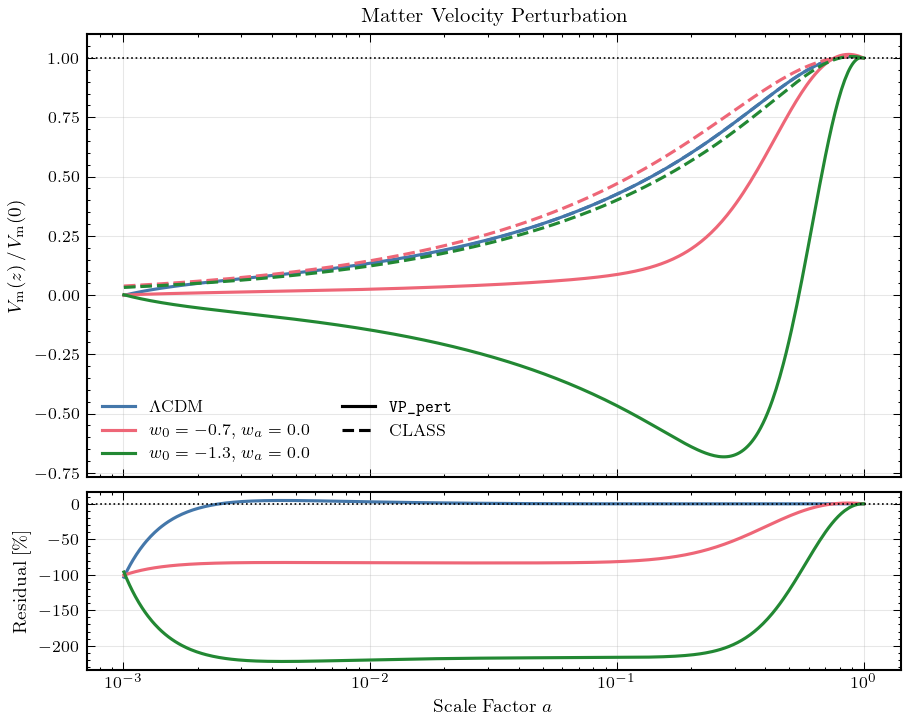

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (lbl, (w0, wa)) in enumerate(de_models.items()):
    z    = cl_data[lbl]['z']
    aa   = 1 / (1 + z)
    y_cl = cl_data[lbl]['V_m']
    y_vp = vp_data[lbl]['V_m']
    y_cl_n = y_cl / y_cl[-1]
    y_vp_n = y_vp / y_vp[-1]
    ax1.semilogx(aa, y_cl_n, color=COLORS[i], ls='--', lw=1.5)
    ax1.semilogx(aa, y_vp_n, color=COLORS[i], lw=1.5, label=lbl)
    ax2.semilogx(aa, 100 * (y_vp_n / y_cl_n - 1), color=COLORS[i])

handles, _ = ax1.get_legend_handles_labels()
custom = [Line2D([0],[0], color='k', lw=1.5,        label=r'\texttt{VP\_pert}'),
          Line2D([0],[0], color='k', lw=1.5, ls='--', label='CLASS')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)
ax1.axhline(1, color='k', lw=0.8, ls=':')
ax1.set_ylabel(r'$V_{\rm m}(z)\,/\,V_{\rm m}(0)$')
ax1.set_title('Matter Velocity Perturbation')
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Scale Factor $a$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())
plt.savefig('figs/theta_m.pdf', bbox_inches='tight')
plt.show()

## 4 — Dark Energy Overdensity $\delta_{\rm DE}(z)$

$\Lambda$CDM has no DE perturbations and is skipped.
Normalized by $\delta_{\rm DE}(z=0)$ from each code to show the relative amplitude.

<!-- > **Note on the amplitude offset**: CLASS includes radiation and initializes from a much earlier
> epoch, which shifts the DE perturbation amplitude relative to VP\_pert. The shapes (slope of
> growth) should agree to $\lesssim 10\%$. -->

In [112]:
def plot_de():
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(10, 6), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

    for i, (lbl, (w0, wa)) in enumerate(de_models.items()):
        if w0 == -1.0 and wa == 0.0:
            continue
        z    = cl_data[lbl]['z']
        aa = 1 / (1+z)
        dde_cl = cl_data[lbl]['delta_de']
        dde_vp = vp_data[lbl]['delta_de']
        dde_cl_n = dde_cl #/ dde_cl[-1]
        dde_vp_n = dde_vp #/ dde_vp[-1]

        vde_cl = cl_data[lbl]['V_DE']
        vde_vp = vp_data[lbl]['V_DE']
        vde_cl_n = vde_cl #/ vde_cl[-1]
        vde_vp_n = vde_vp #/ vde_vp[-1]

        ax1[0].semilogx(aa, dde_cl_n,                        color=COLORS[i],alpha=0.7, ls='--', lw=1.5)
        ax1[0].semilogx(aa, dde_vp_n,                        color=COLORS[i],alpha=0.7, lw=1.5, label=lbl)
        ax2[0].semilogx(aa, 100 * (dde_vp_n / dde_cl_n - 1),   color=COLORS[i],alpha=0.7,)

        ax1[1].semilogx(aa, vde_cl_n, color=COLORS[i], ls='--', lw=1.5)
        ax1[1].semilogx(aa, vde_vp_n, color=COLORS[i], lw=1.5, label=lbl)
        ax2[1].semilogx(aa, 100 * (vde_vp_n / vde_cl_n - 1), color=COLORS[i])

    proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
             Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
    handles, _ = ax1[0].get_legend_handles_labels()
    ax1[0].legend(handles=handles + custom, fontsize=8, ncol=2)
    ax1[0].set_ylabel(r'$\delta_{\rm DE}(z)$')
    ax2[0].set_xlabel(r'Scale Factor $a$')
    ax2[0].set_ylabel(r'Residual [\%]')
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator())

    proxy = [Line2D([0], [0], color='k', lw=1.5,         label=r'\texttt{VP\_pert}'),
             Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
    handles, _ = ax1[1].get_legend_handles_labels()
    ax1[1].legend(handles=handles + proxy, ncol=2)
    ax1[1].set_ylabel(r'$V_{\rm DE}(z)$')
    ax2[1].set_xlabel(r'Scale Factor $a$')
    ax2[1].set_ylabel(r'Residual [\%]')
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator())

    ax1[0].set_title(r'Overdensity')
    ax1[1].set_title(r'Velocity Perturbation')

    # ax1[0].set_xlim(4*1e-2, 1)
    # ax1[1].set_xlim(4*1e-2, 1)
    # ax2[0].set_xlim(4*1e-2, 1)
    # ax2[1].set_xlim(4*1e-2, 1)
    
    fig.suptitle('Linear Dark Energy Perturbations')
    plt.savefig('figs/darkenergy_perturbations_small.pdf', bbox_inches='tight')

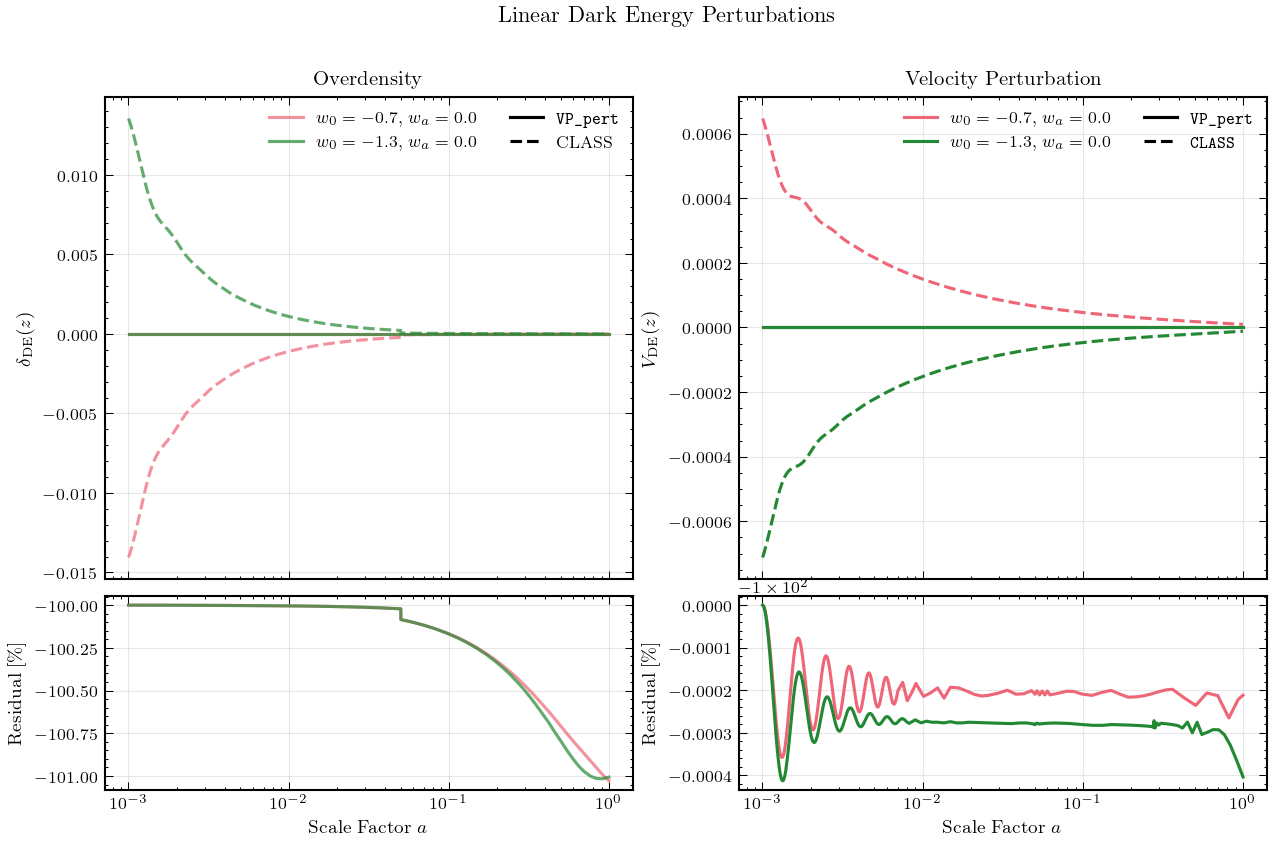

In [113]:
plot_de()

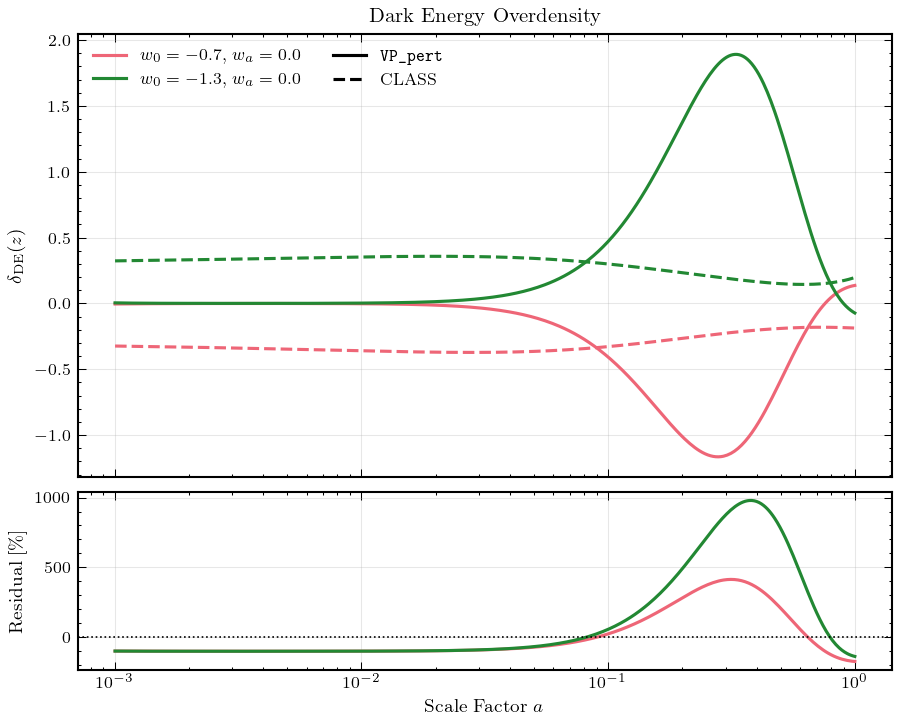

In [47]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (lbl, (w0, wa)) in enumerate(de_models.items()):
    if w0 == -1.0 and wa == 0.0:
        continue
    z = cl_data[lbl]['z']
    aa = 1 / (1 + z)
    y_cl = cl_data[lbl]['delta_de'] #/ cl_data[lbl]['delta_de'][-1]
    y_vp = vp_data[lbl]['delta_de'] # / vp_data[lbl]['delta_de'][-1]
    ax1.semilogx(aa, y_cl, color=COLORS[i], ls='--', lw=1.5)
    ax1.semilogx(aa, y_vp, color=COLORS[i], lw=1.5, label=lbl)
    ax2.semilogx(aa, 100 * (y_vp / y_cl - 1), color=COLORS[i])

handles, _ = ax1.get_legend_handles_labels()
custom = [Line2D([0],[0], color='k', lw=1.5,        label=r'\texttt{VP\_pert}'),
          Line2D([0],[0], color='k', lw=1.5, ls='--', label='CLASS')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)
ax1.set_ylabel(r'$\delta_{\rm DE}(z)$')
ax1.set_title('Dark Energy Overdensity')
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Scale Factor $a$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# ax1.set_xlim([5,0])
# ax2.set_xlim([5,0])
plt.savefig('figs/delta_de.pdf', bbox_inches='tight')
plt.show()

## 5 — Dark Energy Velocity Perturbation $V_{\rm DE}(z)$

$\Lambda$CDM is skipped. Normalized by $V_{\rm DE}(z=0)$.

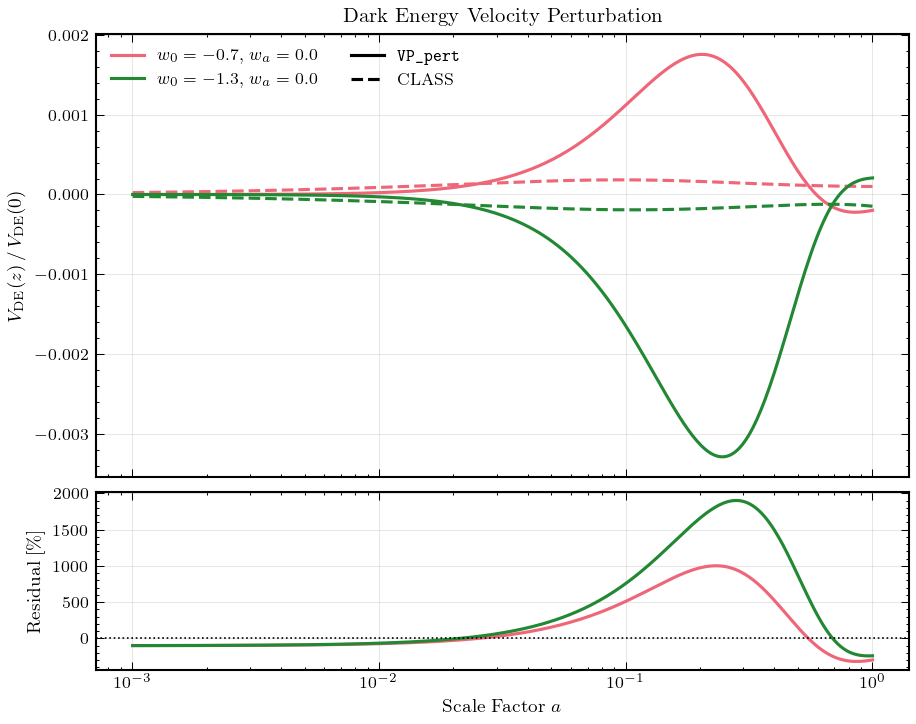

In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (lbl, (w0, wa)) in enumerate(de_models.items()):
    if w0 == -1.0 and wa == 0.0:
        continue
    # elif w0 == -0.7 and wa == -0.6:
        # continue
    z = cl_data[lbl]['z']
    aa = 1 / (1+z)
    y_cl = cl_data[lbl]['V_DE'] #/ cl_data[lbl]['V_DE'][-1]
    y_vp = vp_data[lbl]['V_DE'] #/ vp_data[lbl]['V_DE'][-1]
    ax1.semilogx(aa, y_cl, color=COLORS[i], ls='--', lw=1.5)
    ax1.semilogx(aa, y_vp, color=COLORS[i], lw=1.5, label=lbl)
    ax2.semilogx(aa, 100 * (y_vp / y_cl - 1), color=COLORS[i])

handles, _ = ax1.get_legend_handles_labels()
custom = [Line2D([0],[0], color='k', lw=1.5,        label=r'\texttt{VP\_pert}'),
          Line2D([0],[0], color='k', lw=1.5, ls='--', label='CLASS')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)
ax1.set_ylabel(r'$V_{\rm DE}(z)\,/\,V_{\rm DE}(0)$')
ax1.set_title('Dark Energy Velocity Perturbation')
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Scale Factor $a$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# ax1.set_xlim([5,0])
# ax2.set_xlim([5,0])
plt.savefig('figs/theta_de.pdf', bbox_inches='tight')
plt.show()

## 6 — Gravitational Potential $\Phi(z)$

Normalized to $\Phi(z=0)$ independently for each code.
On super-Hubble scales $\Phi$ is conserved; on sub-Hubble scales it decays during $\Lambda$CDM domination.

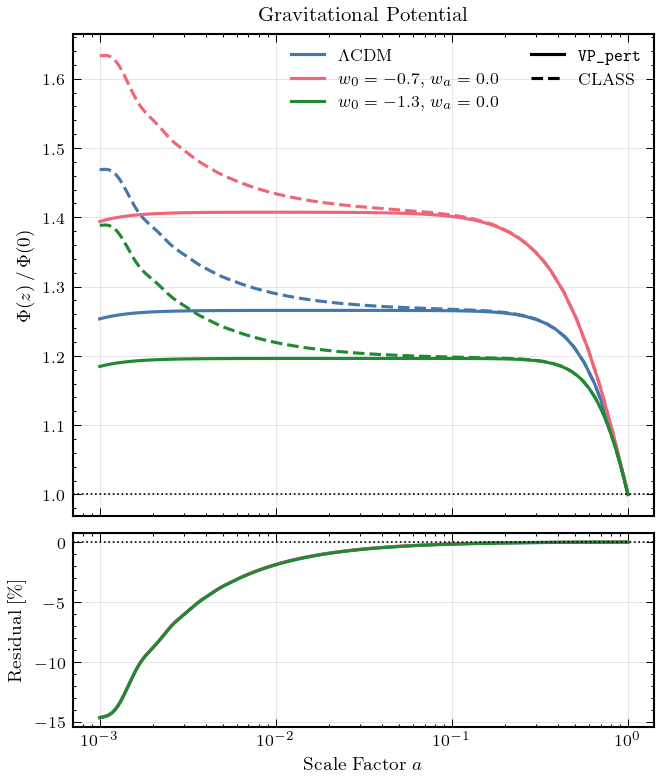

In [120]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (lbl, (w0, wa)) in enumerate(de_models.items()):
    z    = cl_data[lbl]['z']
    aa   = 1 / (1 + z)
    y_cl = cl_data[lbl]['phi']
    y_vp = vp_data[lbl]['phi']
    y_cl_n = y_cl / y_cl[-1]
    y_vp_n = y_vp / y_vp[-1]
    ax1.semilogx(aa, y_cl_n, color=COLORS[i], ls='--', lw=1.5)
    ax1.semilogx(aa, y_vp_n, color=COLORS[i], lw=1.5, label=lbl)
    ax2.semilogx(aa, 100 * (y_vp_n / y_cl_n - 1), color=COLORS[i])

handles, _ = ax1.get_legend_handles_labels()
custom = [Line2D([0],[0], color='k', lw=1.5,        label=r'\texttt{VP\_pert}'),
          Line2D([0],[0], color='k', lw=1.5, ls='--', label='CLASS')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)
ax1.axhline(1, color='k', lw=0.8, ls=':')
ax1.set_ylabel(r'$\Phi(z)\,/\,\Phi(0)$')
ax1.set_title('Gravitational Potential')
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Scale Factor $a$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())

plt.savefig('figs/phi.pdf', bbox_inches='tight')
plt.show()

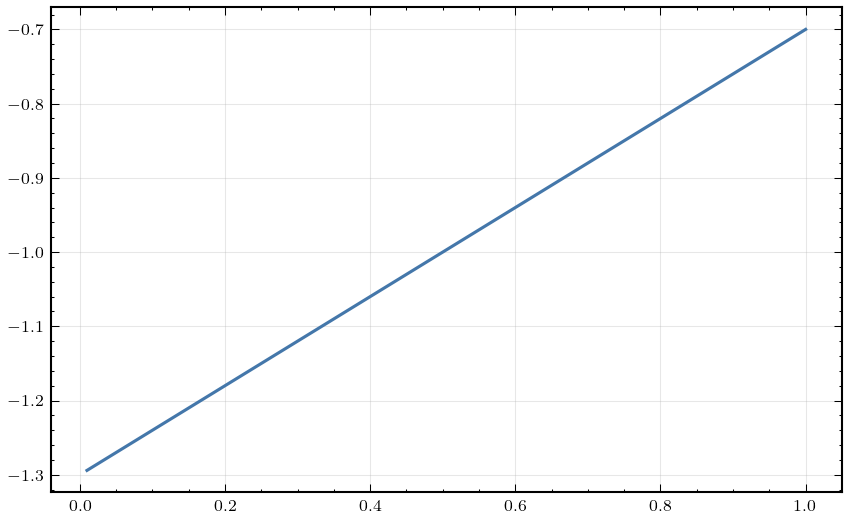

In [12]:
plt.plot(aa, -0.7 - 0.6* (1-aa))

In [13]:
for c in class_cosmos.values():
    c.struct_cleanup()
print('CLASS objects freed.')

CLASS objects freed.
